# Etapa 4: Análise Exploratória dos Dados (EDA)

**Projeto Integrador (P15):** Previsão de Alta Demanda de Produtos da Bioeconomia Amazônica
Disciplina Banco de Dados e Engenharia de Dados para IA, Prof. Adolfo Colares, [UNIFAP – Universidade Federal do Amapá](https://www.unifap.br/)
Autor: Leonam Souza dos Santos Azevedo

**Objetivo:** entender o comportamento das vendas de açaí, castanha-do-pará e óleo de copaíba nos municípios do Amapá, Pará e Amazonas antes de construir as features e o modelo de classificação.

**Fonte:** modelo estrela do PostgreSQL (schema `dw`), preenchido pelo ETL da Etapa 3. Se o banco não estiver disponível, o notebook usa a cópia em `data/processed`, com o mesmo conteúdo.

> As vendas são simuladas a partir de regras documentadas no README (população, produção do ano anterior, sazonalidade, tendência e ruído). Por isso, esta análise tem dois papéis: verificar se essas regras aparecem nos dados depois de todo o pipeline e orientar as escolhas da modelagem.

**Roteiro**

1. Carga e visão geral
2. Qualidade dos dados
3. Distribuição das vendas
4. Evolução temporal
5. Sazonalidade de quantidade e preço
6. Geografia e população
7. Produção extrativa (PEVS) e vendas
8. Prévia da variável alvo
9. Sinais candidatos a features
10. Conclusões para a engenharia de features

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src import config
from src.features import adicionar_alvo
from src.leitura import carregar_dw, montar_base_vendas

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

CORES = {"Açaí": "#5b2a6e", "Castanha-do-pará": "#8c5a2b", "Óleo de copaíba": "#c9a227"}
MESES = ["jan", "fev", "mar", "abr", "mai", "jun", "jul", "ago", "set", "out", "nov", "dez"]

FIGURAS = config.REPORTS_DIR / "figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)

def salvar(fig, nome):
    """Salva a figura em reports/figuras para uso no README e no relatório."""
    fig.savefig(FIGURAS / f"{nome}.png", bbox_inches="tight", dpi=150)

## 1. Carga e visão geral

In [2]:
dw, origem = carregar_dw()
print(f"Fonte dos dados: {origem}\n")
for nome, tabela in dw.items():
    print(f"{nome:26s} {len(tabela):>7,} linhas x {tabela.shape[1]} colunas")

UNIDADE = dict(zip(dw["dim_produto"]["nome"], dw["dim_produto"]["unidade_venda"]))

Fonte dos dados: PostgreSQL (schema dw)

dim_municipio                  222 linhas x 6 colunas
dim_produto                      3 linhas x 4 colunas
dim_tempo                       36 linhas x 6 colunas
fato_producao_extrativa      2,664 linhas x 6 colunas
fato_vendas                 23,975 linhas x 6 colunas


A análise usa uma **base única de vendas**: o fato de vendas unido às dimensões de município, produto e tempo, e à produção extrativa do **ano anterior** (a PEVS de um ano só é publicada no ano seguinte, então é a informação que estaria disponível na hora de prever).

In [3]:
base = montar_base_vendas(dw)
print(f"Base de vendas: {base.shape[0]:,} linhas x {base.shape[1]} colunas")
base.head()

Base de vendas: 23,975 linhas x 22 colunas


,cod_ibge,id_produto,id_tempo,quantidade,preco_unitario,receita,municipio,uf,regiao_intermediaria,regiao_imediata,...,nome,unidade_venda,data_referencia,ano,mes,trimestre,nome_mes,producao_ano_anterior_t,producao_dois_anos_antes_t,ano_producao
0,1300029,1,202201,481.90,12.31,"5,932.19",Alvarães,AM,Tefé,Tefé,...,Açaí,kg,2022-01-01,2022,1,1,janeiro,132.00,NaN,2021
1,1300029,1,202202,324.20,11.23,"3,640.77",Alvarães,AM,Tefé,Tefé,...,Açaí,kg,2022-02-01,2022,2,1,fevereiro,132.00,NaN,2021
2,1300029,1,202203,318.00,13.41,"4,264.38",Alvarães,AM,Tefé,Tefé,...,Açaí,kg,2022-03-01,2022,3,1,março,132.00,NaN,2021
3,1300029,1,202204,228.20,12.74,"2,907.27",Alvarães,AM,Tefé,Tefé,...,Açaí,kg,2022-04-01,2022,4,2,abril,132.00,NaN,2021
4,1300029,1,202205,255.60,12.96,"3,312.58",Alvarães,AM,Tefé,Tefé,...,Açaí,kg,2022-05-01,2022,5,2,maio,132.00,NaN,2021


In [4]:
resumo = base.groupby("nome").agg(
    registros=("quantidade", "size"),
    municipios=("cod_ibge", "nunique"),
    meses=("id_tempo", "nunique"),
    quantidade_media=("quantidade", "mean"),
    quantidade_mediana=("quantidade", "median"),
    preco_medio=("preco_unitario", "mean"),
    receita_total_milhoes=("receita", lambda s: s.sum() / 1e6),
)
resumo["unidade"] = resumo.index.map(UNIDADE)
resumo

,registros,municipios,meses,quantidade_media,quantidade_mediana,preco_medio,receita_total_milhoes,unidade
nome,,,,,,,,
Açaí,7992,222,36,"1,420.88",782.65,11.77,127.22,kg
Castanha-do-pará,7992,222,36,139.88,80.30,45.44,50.00,kg
Óleo de copaíba,7991,222,36,18.39,10.80,92.95,13.64,L


Em todos os produtos a **média é bem maior que a mediana**: poucos municípios grandes concentram o volume vendido. Esse ponto é aprofundado nas seções 3 e 6.

In [5]:
ausentes = base.isna().sum()
ausentes = ausentes[ausentes > 0].to_frame("ausentes")
ausentes["percentual"] = 100 * ausentes["ausentes"] / len(base)
ausentes

,ausentes,percentual
producao_ano_anterior_t,1260,5.26
producao_dois_anos_antes_t,8928,37.24


Os únicos campos com ausências são os de produção extrativa, por dois motivos: os casos em que o IBGE publicou `...` (dado não disponível), mantidos como `NULL` pelo ETL, e, para as vendas de 2022, a produção de dois anos antes (2020), que fica fora do período coletado. Como 2022 serve apenas de histórico para o alvo, isso não afeta a modelagem; nos demais casos, a ausência será tratada como informação própria, sem descartar as vendas.

## 2. Qualidade dos dados

In [6]:
qualidade = pd.read_csv(config.REPORTS_DIR / "qualidade_etl.csv")
qualidade[qualidade["registros"] > 0].reset_index(drop=True)

,tabela,regra,registros
0,dim_municipio,registros lidos da staging,222
1,fato_producao_extrativa,registros lidos da staging (todos os produtos),111888
2,fato_producao_extrativa,registros dos 3 produtos do projeto (demais ig...,5328
3,fato_producao_extrativa,símbolo '-' do IBGE convertido em zero,2150
4,fato_producao_extrativa,"símbolos '...', '..' ou 'X' do IBGE convertido...",264
5,fato_producao_extrativa,registros gravados,2664
6,fato_vendas,registros lidos da staging,24167
7,fato_vendas,linhas duplicadas removidas,191
8,fato_vendas,nome do produto padronizado,3596
9,fato_vendas,mês convertido de MM/AAAA,2397


In [7]:
verificacoes = {
    "chave município + produto + mês única": not base.duplicated(["cod_ibge", "id_produto", "id_tempo"]).any(),
    "quantidades não negativas": bool((base["quantidade"] >= 0).all()),
    "preços positivos": bool((base["preco_unitario"] > 0).all()),
    "receita = quantidade x preço (tolerância de 1%)": bool(
        np.allclose(base["quantidade"] * base["preco_unitario"], base["receita"], rtol=0.01, atol=0.05)
    ),
}
display(pd.Series(verificacoes, name="resultado").to_frame())

meses_por_serie = base.groupby(["cod_ibge", "id_produto"]).size().value_counts().rename_axis("meses na série")
meses_por_serie.to_frame("séries (município + produto)")

,resultado
chave município + produto + mês única,True
quantidades não negativas,True
preços positivos,True
receita = quantidade x preço (tolerância de 1%),True


,séries (município + produto)
meses na série,
36,665
35,1


Depois do ETL, a base passa em todas as verificações de consistência. Quase todas as séries município + produto têm os 36 meses completos; a exceção corresponde ao registro descartado pelo ETL por preço implausível. As features de defasagem (Etapa 5) serão calculadas pelo calendário, para não confundir um mês ausente com o mês anterior.

## 3. Distribuição das vendas

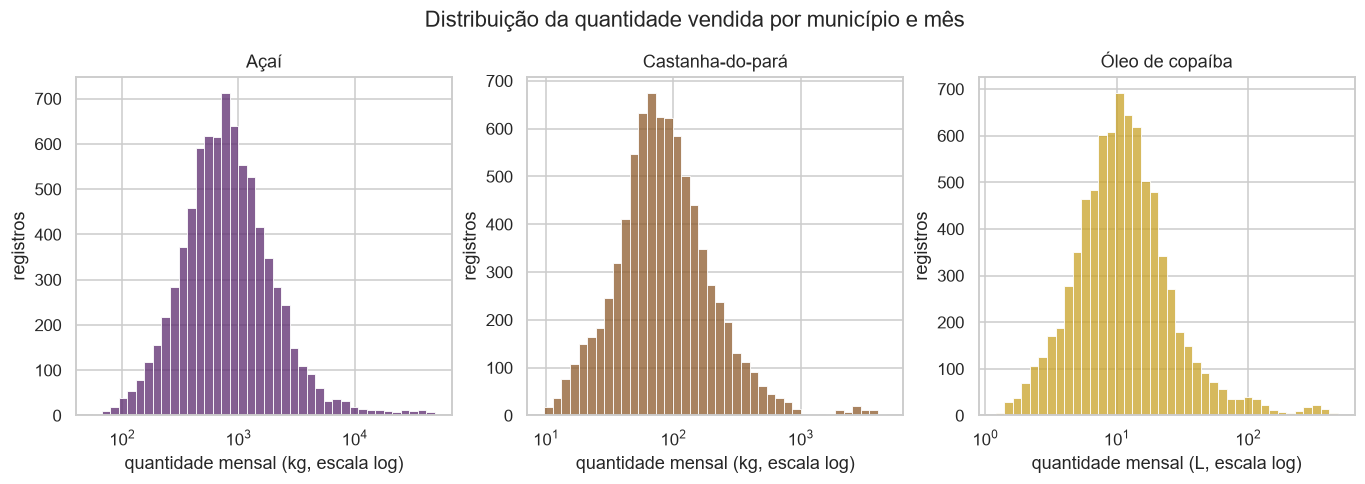

,assimetria_original,assimetria_em_log
nome,,
Açaí,8.92,0.63
Castanha-do-pará,8.92,0.68
Óleo de copaíba,7.30,0.98


In [8]:
fig, eixos = plt.subplots(1, 3, figsize=(15, 4))
for eixo, (produto, grupo) in zip(eixos, base.groupby("nome")):
    sns.histplot(grupo["quantidade"], bins=40, log_scale=True, color=CORES[produto], ax=eixo)
    eixo.set_title(produto)
    eixo.set_xlabel(f"quantidade mensal ({UNIDADE[produto]}, escala log)")
    eixo.set_ylabel("registros")
fig.suptitle("Distribuição da quantidade vendida por município e mês", y=1.03)
salvar(fig, "01_distribuicao_quantidade")
plt.show()

base.groupby("nome")["quantidade"].agg(
    assimetria_original="skew",
    assimetria_em_log=lambda s: np.log1p(s).skew(),
)

A quantidade vendida é **fortemente assimétrica à direita** e fica próxima de simétrica em escala logarítmica. Duas consequências para a modelagem:

- variáveis de volume entram nas features em **log** ou como **razões** em relação ao histórico;
- o alvo compara cada município com o **próprio histórico**, para que o modelo não aprenda apenas o tamanho do município.

## 4. Evolução temporal

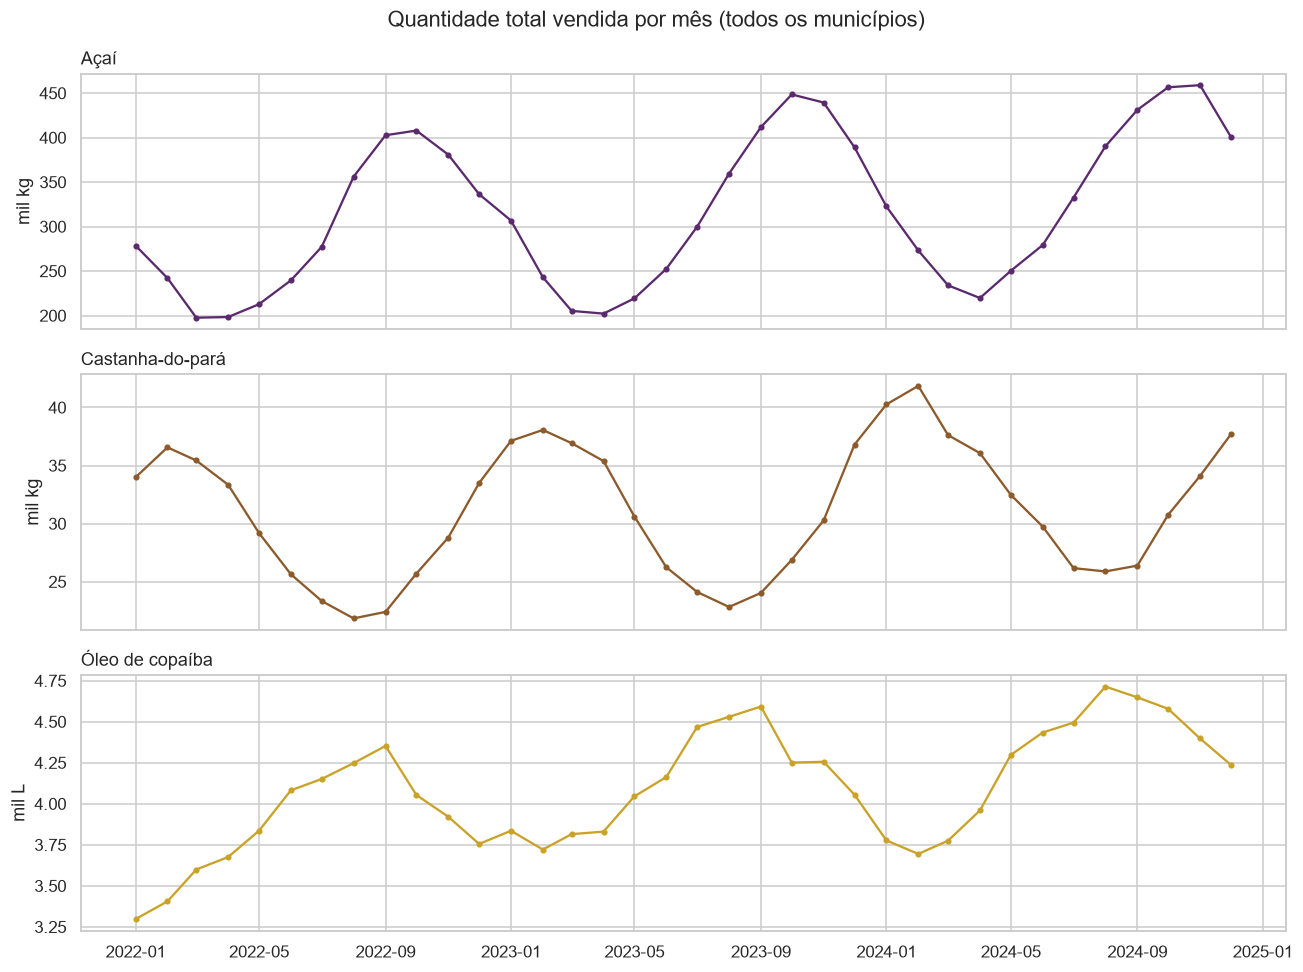

ano,2022,2023,2024,crescimento_2022_2024_%
nome,,,,
Açaí,"3,529,833.00","3,776,871.20","4,048,985.00",14.71
Castanha-do-pará,"349,689.70","369,243.00","398,974.20",14.09
Óleo de copaíba,"46,375.10","49,560.30","51,005.80",9.99


In [9]:
mensal = base.groupby(["data_referencia", "nome"])["quantidade"].sum().unstack("nome")

fig, eixos = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for eixo, produto in zip(eixos, mensal.columns):
    eixo.plot(mensal.index, mensal[produto] / 1000, color=CORES[produto], marker="o", markersize=3)
    eixo.set_title(produto, loc="left")
    eixo.set_ylabel(f"mil {UNIDADE[produto]}")
fig.suptitle("Quantidade total vendida por mês (todos os municípios)")
fig.tight_layout()
salvar(fig, "02_evolucao_mensal")
plt.show()

anual = base.pivot_table(index="nome", columns="ano", values="quantidade", aggfunc="sum")
anual["crescimento_2022_2024_%"] = 100 * (anual[2024] / anual[2022] - 1)
anual

As três séries combinam **tendência de crescimento** com **ciclos anuais que se repetem** de forma estável. Isso indica que o mês do ano e o comportamento do mesmo período no ano anterior devem ser bons preditores.

## 5. Sazonalidade de quantidade e preço

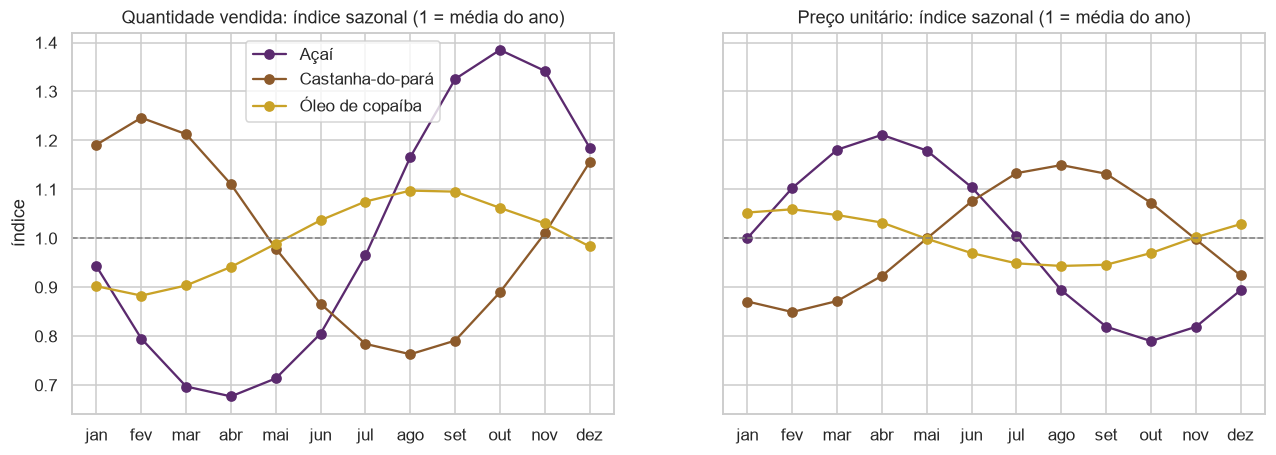

,mês de pico,índice no pico,mês de vale,índice no vale,correlação quantidade x preço
nome,,,,,
Açaí,out,1.39,abr,0.68,-0.99
Castanha-do-pará,fev,1.25,ago,0.76,-1.00
Óleo de copaíba,ago,1.10,fev,0.88,-0.97


In [10]:
# Índice sazonal: valor do mês dividido pela média do mesmo município, produto e ano.
# Remove o efeito do tamanho do município e da tendência, isolando o padrão do calendário.
grupo_ano = base.groupby(["cod_ibge", "id_produto", "ano"])
indices = base.assign(
    indice_quantidade=base["quantidade"] / grupo_ano["quantidade"].transform("mean"),
    indice_preco=base["preco_unitario"] / grupo_ano["preco_unitario"].transform("mean"),
)
sazonal = indices.groupby(["mes", "nome"])[["indice_quantidade", "indice_preco"]].mean().unstack("nome")

fig, eixos = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for produto in sazonal["indice_quantidade"].columns:
    eixos[0].plot(sazonal.index, sazonal["indice_quantidade"][produto], marker="o", color=CORES[produto], label=produto)
    eixos[1].plot(sazonal.index, sazonal["indice_preco"][produto], marker="o", color=CORES[produto], label=produto)
for eixo, titulo in zip(eixos, ["Quantidade vendida", "Preço unitário"]):
    eixo.axhline(1, color="gray", linestyle="--", linewidth=1)
    eixo.set_xticks(range(1, 13))
    eixo.set_xticklabels(MESES)
    eixo.set_title(f"{titulo}: índice sazonal (1 = média do ano)")
eixos[0].set_ylabel("índice")
eixos[0].legend()
salvar(fig, "03_sazonalidade")
plt.show()

produtos = sazonal["indice_quantidade"].columns
pd.DataFrame(
    {
        "mês de pico": sazonal["indice_quantidade"].idxmax().map(lambda m: MESES[m - 1]),
        "índice no pico": sazonal["indice_quantidade"].max(),
        "mês de vale": sazonal["indice_quantidade"].idxmin().map(lambda m: MESES[m - 1]),
        "índice no vale": sazonal["indice_quantidade"].min(),
        "correlação quantidade x preço": [
            np.corrcoef(sazonal["indice_quantidade"][p], sazonal["indice_preco"][p])[0, 1] for p in produtos
        ],
    }
)

- **Açaí:** pico de vendas no segundo semestre, com máximo em outubro, e vale em abril, coerente com a safra paraense.
- **Castanha-do-pará:** pico em fevereiro, no período de coleta das chuvas, e vale em agosto.
- **Óleo de copaíba:** variação pequena ao longo do ano.
- **Preço:** move-se no sentido **oposto** à quantidade (correlação negativa): na safra há mais oferta, o preço cai e as vendas sobem.

Como cada produto tem o seu próprio calendário, o mês precisa entrar no modelo **combinado com o produto**. O preço do mês anterior, relativo ao seu histórico, também carrega informação sobre a fase da safra.

## 6. Geografia e população

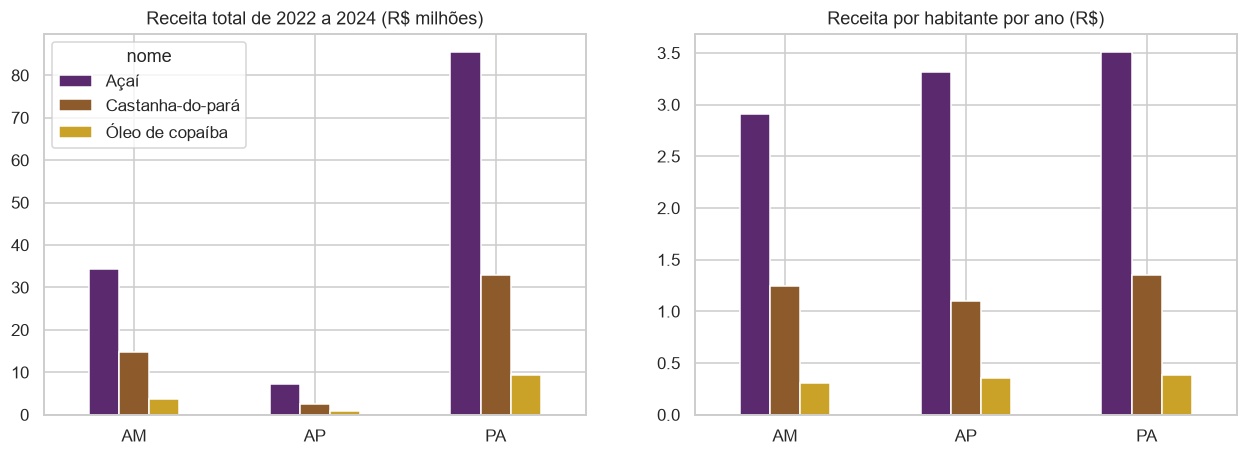

nome,Açaí,Castanha-do-pará,Óleo de copaíba
uf,,,
AM,2.91,1.25,0.30
AP,3.32,1.10,0.35
PA,3.51,1.35,0.38


In [11]:
populacao_uf = dw["dim_municipio"].groupby("uf")["populacao_2022"].sum()
receita_uf = base.pivot_table(index="uf", columns="nome", values="receita", aggfunc="sum")
receita_per_capita = receita_uf.div(populacao_uf, axis=0) / base["ano"].nunique()

fig, eixos = plt.subplots(1, 2, figsize=(14, 4.5))
cores = [CORES[p] for p in receita_uf.columns]
(receita_uf / 1e6).plot.bar(ax=eixos[0], color=cores, rot=0)
eixos[0].set_title("Receita total de 2022 a 2024 (R$ milhões)")
eixos[0].set_xlabel("")
receita_per_capita.plot.bar(ax=eixos[1], color=cores, rot=0, legend=False)
eixos[1].set_title("Receita por habitante por ano (R$)")
eixos[1].set_xlabel("")
salvar(fig, "04_receita_por_uf")
plt.show()

receita_per_capita

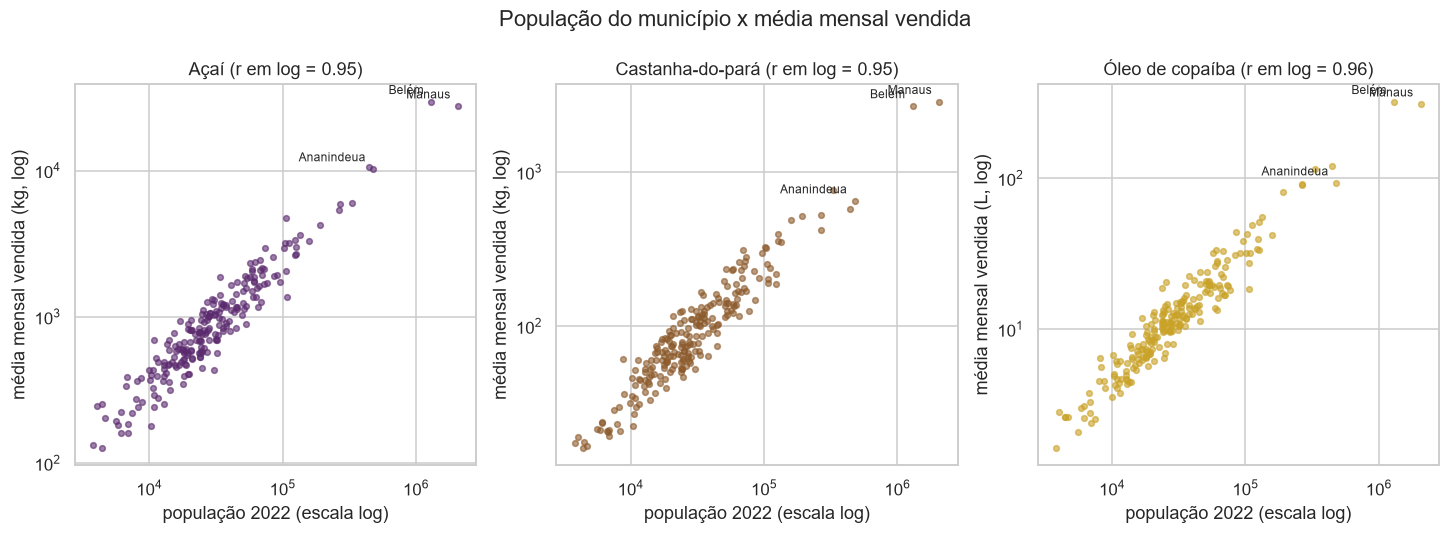

,correlação log-log
Açaí,0.95
Castanha-do-pará,0.95
Óleo de copaíba,0.96


In [12]:
por_municipio = base.groupby(["cod_ibge", "municipio", "uf", "nome"], as_index=False).agg(
    populacao=("populacao_2022", "first"),
    quantidade_media=("quantidade", "mean"),
)

fig, eixos = plt.subplots(1, 3, figsize=(16, 4.5))
correlacoes = {}
for eixo, (produto, grupo) in zip(eixos, por_municipio.groupby("nome")):
    eixo.scatter(grupo["populacao"], grupo["quantidade_media"], s=14, alpha=0.6, color=CORES[produto])
    eixo.set_xscale("log")
    eixo.set_yscale("log")
    correlacoes[produto] = np.corrcoef(np.log(grupo["populacao"]), np.log(grupo["quantidade_media"]))[0, 1]
    eixo.set_title(f"{produto} (r em log = {correlacoes[produto]:.2f})")
    eixo.set_xlabel("população 2022 (escala log)")
    eixo.set_ylabel(f"média mensal vendida ({UNIDADE[produto]}, log)")
    for _, linha in grupo.nlargest(3, "populacao").iterrows():
        eixo.annotate(linha["municipio"], (linha["populacao"], linha["quantidade_media"]), fontsize=8,
                      xytext=(-5, 5), textcoords="offset points", ha="right")
fig.suptitle("População do município x média mensal vendida", y=1.03)
salvar(fig, "05_populacao_vendas")
plt.show()

pd.Series(correlacoes, name="correlação log-log").to_frame()

A relação entre população e volume vendido é **quase linear em escala log-log**, com correlação alta nos três produtos: a população explica a maior parte do **nível** de vendas de cada município. Por isso a população entra no modelo apenas como variável de contexto (em log), enquanto o alvo mede a variação em relação ao próprio histórico.

## 7. Produção extrativa (PEVS) e vendas

In [13]:
pevs = dw["fato_producao_extrativa"].merge(dw["dim_produto"], on="id_produto")
situacao = np.select(
    [pevs["quantidade_produzida"].isna(), pevs["quantidade_produzida"] == 0],
    ["não disponível (NULL)", "sem produção (zero)"],
    default="com produção",
)
situacao = pd.Series(situacao, index=pevs.index, name="situação na PEVS")
pd.crosstab(pevs["nome"], situacao, normalize="index").mul(100).round(1).rename_axis(index="% dos registros (município + ano)")

situação na PEVS,com produção,não disponível (NULL),sem produção (zero)
% dos registros (município + ano),,,
Açaí,85.60,5.00,9.50
Castanha-do-pará,51.60,5.00,43.50
Óleo de copaíba,13.10,5.00,82.00


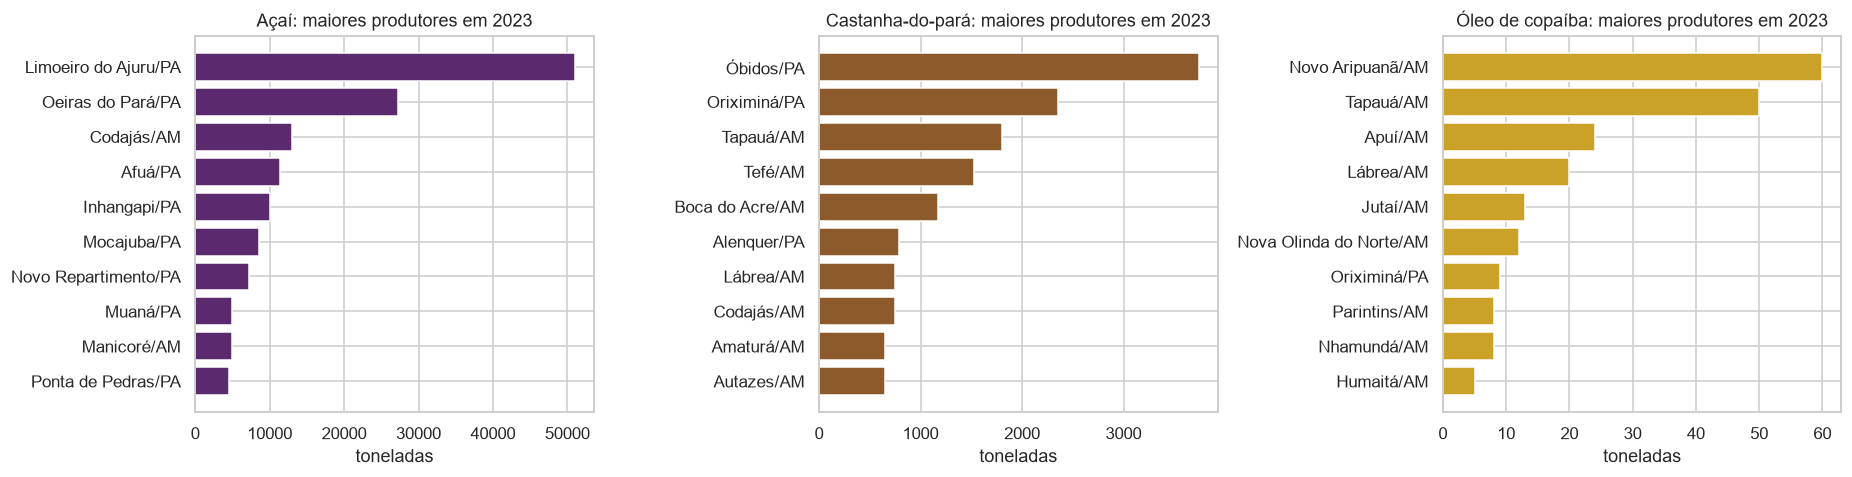

In [14]:
ano_ref = int(base["ano_producao"].max())
producao_ref = pevs[pevs["ano"] == ano_ref].merge(dw["dim_municipio"][["cod_ibge", "municipio", "uf"]], on="cod_ibge")

fig, eixos = plt.subplots(1, 3, figsize=(17, 4.5))
for eixo, (produto, grupo) in zip(eixos, producao_ref.groupby("nome")):
    top = grupo.nlargest(10, "quantidade_produzida").sort_values("quantidade_produzida")
    eixo.barh(top["municipio"] + "/" + top["uf"], top["quantidade_produzida"], color=CORES[produto])
    eixo.set_title(f"{produto}: maiores produtores em {ano_ref}")
    eixo.set_xlabel("toneladas")
fig.tight_layout()
salvar(fig, "06_maiores_produtores")
plt.show()

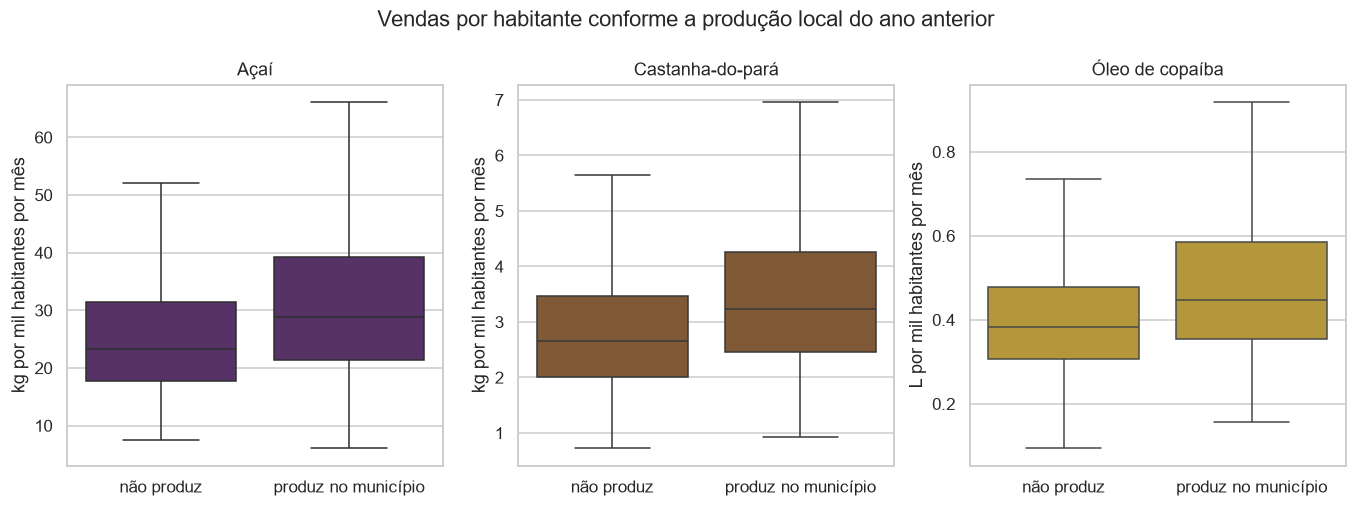

producao_local,não produz,produz no município,diferença_%
nome,,,
Açaí,23.30,28.87,23.92
Castanha-do-pará,2.67,3.24,21.41
Óleo de copaíba,0.38,0.45,16.74


In [15]:
vendas_relativas = base.assign(
    vendas_por_mil_hab=base["quantidade"] / base["populacao_2022"] * 1000,
    producao_local=np.where(base["producao_ano_anterior_t"].fillna(0) > 0, "produz no município", "não produz"),
)
ordem = ["não produz", "produz no município"]

fig, eixos = plt.subplots(1, 3, figsize=(15, 4.5))
for eixo, (produto, grupo) in zip(eixos, vendas_relativas.groupby("nome")):
    sns.boxplot(data=grupo, x="producao_local", y="vendas_por_mil_hab", order=ordem,
                color=CORES[produto], showfliers=False, ax=eixo)
    eixo.set_title(produto)
    eixo.set_xlabel("")
    eixo.set_ylabel(f"{UNIDADE[produto]} por mil habitantes por mês")
fig.suptitle("Vendas por habitante conforme a produção local do ano anterior", y=1.03)
salvar(fig, "07_producao_local_vendas")
plt.show()

comparacao = (
    vendas_relativas.groupby(["nome", "producao_local"])["vendas_por_mil_hab"].median().unstack().reindex(columns=ordem)
)
comparacao["diferença_%"] = 100 * (comparacao["produz no município"] / comparacao["não produz"] - 1)
comparacao

Os grandes produtores da PEVS são, em geral, municípios pequenos do interior; produção e consumo não coincidem. Ainda assim, onde há **produção local no ano anterior** as vendas por habitante tendem a ser maiores (oferta mais próxima e preço menor). A produção do ano anterior (em log) e um indicador "produz no município" entram como features de contexto.

## 8. Prévia da variável alvo

**Definição:** `alta_demanda = 1` quando a quantidade vendida no mês supera a **média dos 12 meses anteriores** do mesmo município e produto; caso contrário, `0`.

- Compara cada município com o seu próprio histórico.
- Usa apenas meses passados, sem olhar o próprio mês nem o futuro.
- Os meses de 2022 servem só de histórico; o alvo existe de jan/2023 a dez/2024.

In [16]:
com_alvo = adicionar_alvo(base)
serie = com_alvo.groupby(["cod_ibge", "id_produto"])
com_alvo["alta_mes_anterior"] = serie["alta_demanda"].shift(1).astype("Float64")

modelagem = com_alvo[com_alvo["alta_demanda"].notna()].copy()
modelagem["alta_demanda"] = modelagem["alta_demanda"].astype(int)
print(f"Registros com alvo: {len(modelagem):,} de {len(base):,} ({modelagem['ano'].min()} a {modelagem['ano'].max()})")

balanco = modelagem.groupby("nome")["alta_demanda"].agg(registros="size", taxa_alta_demanda="mean")
balanco.loc["Total"] = [len(modelagem), modelagem["alta_demanda"].mean()]
balanco["registros"] = balanco["registros"].astype(int)
balanco

Registros com alvo: 15,983 de 23,975 (2023 a 2024)


,registros,taxa_alta_demanda
nome,,
Açaí,5328,0.48
Castanha-do-pará,5328,0.51
Óleo de copaíba,5327,0.51
Total,15983,0.50


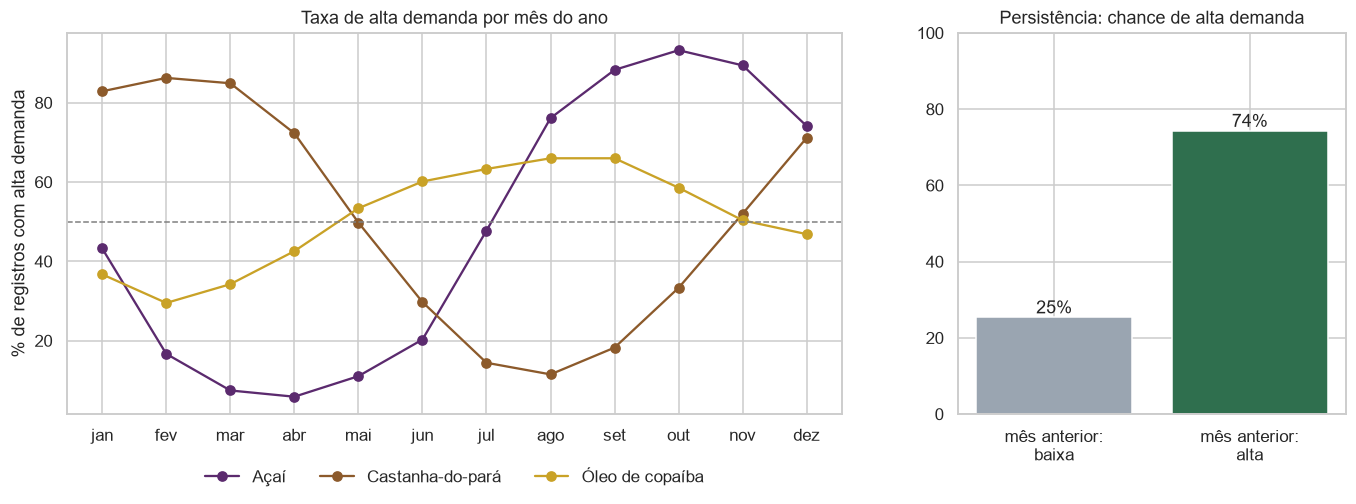

Chance de alta demanda após mês de baixa: 25.4%
Chance de alta demanda após mês de alta:  74.3%


In [17]:
taxa_mes = modelagem.groupby(["mes", "nome"])["alta_demanda"].mean().unstack("nome") * 100
persistencia = (
    modelagem.dropna(subset=["alta_mes_anterior"]).groupby("alta_mes_anterior")["alta_demanda"].mean() * 100
)

fig, eixos = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [2, 1]})
for produto in taxa_mes.columns:
    eixos[0].plot(taxa_mes.index, taxa_mes[produto], marker="o", color=CORES[produto], label=produto)
eixos[0].axhline(50, color="gray", linestyle="--", linewidth=1)
eixos[0].set_xticks(range(1, 13))
eixos[0].set_xticklabels(MESES)
eixos[0].set_ylabel("% de registros com alta demanda")
eixos[0].set_title("Taxa de alta demanda por mês do ano")
eixos[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)

barras = eixos[1].bar(
    ["mês anterior:\nbaixa", "mês anterior:\nalta"],
    [persistencia.get(0.0, np.nan), persistencia.get(1.0, np.nan)],
    color=["#9aa5b1", "#2f6f4e"],
)
eixos[1].bar_label(barras, fmt="%.0f%%")
eixos[1].set_ylim(0, 100)
eixos[1].set_title("Persistência: chance de alta demanda")
salvar(fig, "08_alvo_sazonalidade_persistencia")
plt.show()

print(f"Chance de alta demanda após mês de baixa: {persistencia.get(0.0, np.nan):.1f}%")
print(f"Chance de alta demanda após mês de alta:  {persistencia.get(1.0, np.nan):.1f}%")

- O alvo fica **razoavelmente equilibrado** no total (taxa impressa acima), o que permite usar Accuracy e F1 sem distorção grave; ainda assim, o F1 será a métrica principal.
- A taxa de alta demanda **varia muito ao longo do ano** e com calendários diferentes por produto: a sazonalidade é o sinal mais forte.
- Há **persistência**: depois de um mês de alta demanda, a chance de outro mês de alta é bem maior. Isso justifica features de defasagem (lags).

## 9. Sinais candidatos a features

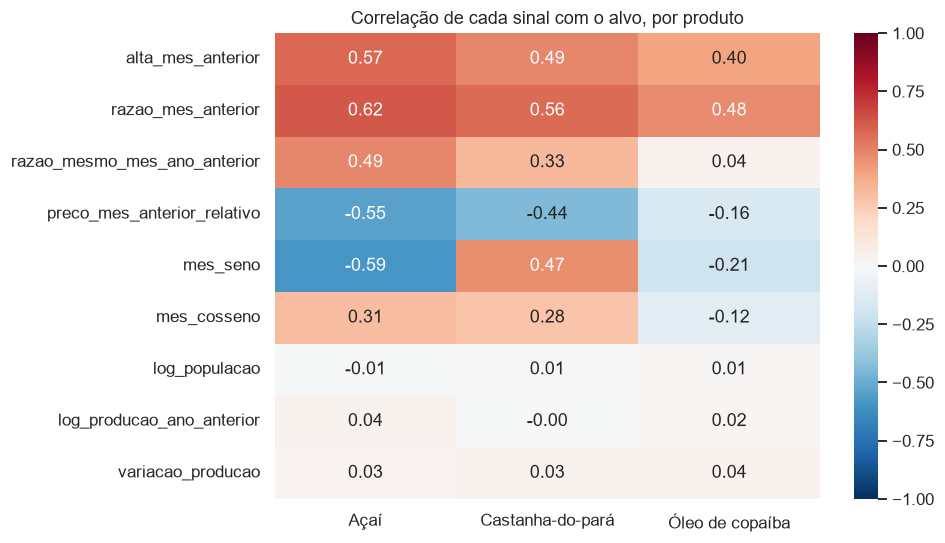

In [18]:
# Sinais calculados só com informação disponível ANTES do mês previsto
sinais = com_alvo.assign(
    razao_mes_anterior=serie["quantidade"].shift(1) / com_alvo["media_12m_anteriores"],
    razao_mesmo_mes_ano_anterior=serie["quantidade"].shift(12) / com_alvo["media_12m_anteriores"],
    preco_mes_anterior_relativo=serie["preco_unitario"].shift(1)
    / serie["preco_unitario"].transform(lambda s: s.shift(1).rolling(12, min_periods=12).mean()),
    mes_seno=np.sin(2 * np.pi * com_alvo["mes"] / 12),
    mes_cosseno=np.cos(2 * np.pi * com_alvo["mes"] / 12),
    log_populacao=np.log(com_alvo["populacao_2022"]),
    log_producao_ano_anterior=np.log1p(com_alvo["producao_ano_anterior_t"]),
    variacao_producao=np.log1p(com_alvo["producao_ano_anterior_t"]) - np.log1p(com_alvo["producao_dois_anos_antes_t"]),
)
sinais = sinais[sinais["alta_demanda"].notna()]
colunas_sinais = [
    "alta_mes_anterior", "razao_mes_anterior", "razao_mesmo_mes_ano_anterior", "preco_mes_anterior_relativo",
    "mes_seno", "mes_cosseno", "log_populacao", "log_producao_ano_anterior", "variacao_producao",
]

correlacao = pd.DataFrame(
    {
        produto: grupo[colunas_sinais].astype(float).corrwith(grupo["alta_demanda"].astype(float))
        for produto, grupo in sinais.groupby("nome")
    }
)

fig, eixo = plt.subplots(figsize=(8, 5.5))
sns.heatmap(correlacao, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=eixo)
eixo.set_title("Correlação de cada sinal com o alvo, por produto")
salvar(fig, "09_correlacao_sinais_alvo")
plt.show()

- Os sinais de **memória recente** (alta demanda no mês anterior e razão entre o mês anterior e a média dos 12 meses) têm as correlações positivas mais fortes com o alvo.
- O **preço do mês anterior**, relativo ao seu histórico, tem correlação negativa: preço em queda indica entrada na safra e vendas acima da média.
- O **seno e o cosseno do mês** mudam de sinal conforme o produto, confirmando que a sazonalidade precisa ser combinada com o produto.
- A **população** praticamente não se correlaciona com o alvo: o alvo relativo neutraliza o tamanho do município, como planejado.
- A **produção extrativa** se relaciona com o alvo principalmente pela **variação** entre os dois anos anteriores (correlação positiva): quando a oferta local cresce, o patamar de vendas sobe e os meses seguintes tendem a ficar acima da média histórica. O nível da produção, sozinho, diz menos, porque o alvo já é relativo ao histórico do município.

## 10. Conclusões para a engenharia de features

| Achado da EDA | Decisão para a Etapa 5 |
|---------------|------------------------|
| Base íntegra após o ETL; uma série com mês ausente | Defasagens calculadas pelo calendário, não pela posição da linha |
| Vendas muito assimétricas e dominadas pela população | Variáveis de volume em log ou como razão sobre a média histórica; população em log |
| Sazonalidade forte e diferente por produto | Mês em seno/cosseno combinado com o produto; taxa histórica de alta demanda no mesmo mês |
| Persistência entre meses consecutivos | Alvo do mês anterior, lags de 1, 2 e 12 meses e médias móveis, sempre sobre o passado |
| Preço inverso à quantidade | Preço do mês anterior relativo ao histórico |
| Produção local aumenta as vendas por habitante | Produção do ano anterior em log, variação em relação ao ano anterior e indicador "produz no município" |
| Dados em série temporal | Validação temporal: treino em 2023 e teste em 2024, sem embaralhar |

As figuras desta análise foram salvas em `reports/figuras/` para uso no README e no relatório final.